In [ ]:
# 🎓 Student Performance Prediction

# This project predicts whether a student will **Pass or Fail** based on factors such as:

# - Study Hours per Week
# - Attendance Rate
# - Previous Grades
# - Participation in Extracurricular Activities
# - Parent Education Level

# Machine Learning model used in this project:
# - **Random Forest Classifier**

# The goal is to analyze which factors influence student success and build a predictive model.

##📌 Conclusion:
# The Random Forest model achieved approximately:
# - Accuracy: ~50%
# - Log Loss: ~0.73

# This indicates that the dataset may have **weak predictive signals**, meaning the available features may not strongly determine student success.

# Future improvements could include:
# - More student behavioral features
# - Better feature engineering
# - Trying advanced models like **XGBoost**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss

In [3]:
df = pd.read_csv("student_performance_prediction.csv")
df.head()
print(df.shape)
print(df.isnull().sum())

(40000, 7)
Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64


In [4]:
df = df[(df["Study Hours per Week"] >= 0) & (df["Study Hours per Week"] <= 100)]
df = df[(df["Attendance Rate"] >= 0) & (df["Attendance Rate"] <= 100)]
df = df[(df["Previous Grades"] >= 0) & (df["Previous Grades"] <= 100)]

df.fillna({
    "Study Hours per Week": df["Study Hours per Week"].median(),
    "Attendance Rate": df["Attendance Rate"].median(),
    "Previous Grades": df["Previous Grades"].median(),
    "Parent Education Level": df["Parent Education Level"].mode()[0],
    "Participation in Extracurricular Activities": df["Participation in Extracurricular Activities"].mode()[0]
}, inplace=True)

df.dropna(subset=["Passed"], inplace=True)

print(df.shape)
print(df.isnull().sum())

(27965, 7)
Student ID                                     0
Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64


In [5]:
order = {
    "Yes": 1,
    "No": 0
}

df["Participation_encoding"] = df["Participation in Extracurricular Activities"].map(order)
df["Passed_encoding"] = df["Passed"].map(order)

df.drop("Participation in Extracurricular Activities", axis=1, inplace=True)
df.drop("Passed", axis=1, inplace=True)

df = pd.get_dummies(df, columns=["Parent Education Level"], drop_first=True)

In [6]:
df["study_attendance"] = df["Study Hours per Week"] * df["Attendance Rate"]

In [7]:
cols_to_check = [
    "Study Hours per Week",
    "Participation_encoding",
    "Attendance Rate",
    "Previous Grades",
    "Passed_encoding"
]

df[cols_to_check].corr()["Passed_encoding"].sort_values()

Study Hours per Week     -0.014170
Previous Grades          -0.004538
Attendance Rate           0.002145
Participation_encoding    0.004284
Passed_encoding           1.000000
Name: Passed_encoding, dtype: float64

In [8]:
X = df.drop(["Student ID", "Passed_encoding"], axis=1)
y = df["Passed_encoding"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [11]:
y_pred = rf.predict(X_test_scaled)
y_pred_proba = rf.predict_proba(X_test_scaled)[:,1]

In [12]:
print("Log Loss:", log_loss(y_test, y_pred_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Log Loss: 0.6932855057189046
Accuracy: 0.5099231181834436
              precision    recall  f1-score   support

           0       0.51      0.61      0.55      2807
           1       0.51      0.41      0.46      2786

    accuracy                           0.51      5593
   macro avg       0.51      0.51      0.51      5593
weighted avg       0.51      0.51      0.51      5593



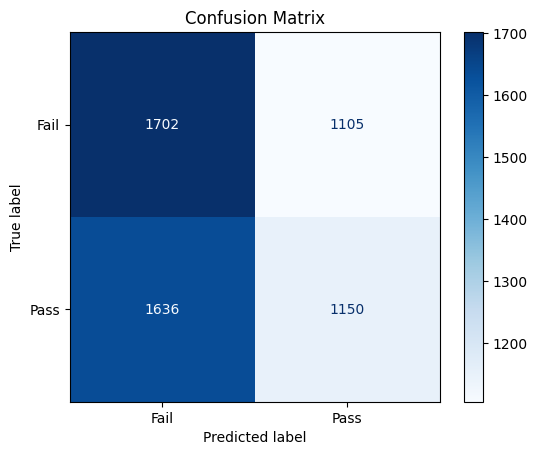

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()